# 02b — Preprocessing (Classification track)

Produces `dataset/PostProcessed_clf.csv`. The pipeline is the same as 02a — audit,
drop leaking columns, stratified split, train-only filters, consensus outlier
detection — with two differences:

- the **imputer study minimises NRMSE** instead of maximising rank correlation,
  because a nominal target cares about reconstructing values accurately rather
  than preserving their order;
- an extra **class-imbalance diagnostic** compares seven resampling techniques.

Both tracks use the same `random_state=42` split, so the two processed files
contain exactly the same rows in Train and Test.

Equivalent to: `python main.py --stage prep-clf`

## 1. Data audit

Identical to 02a: implausible physical measurements become NaN.

In [1]:
# Make the project's src/ package importable from inside notebooks/.
import os
import sys
sys.path.insert(0, os.path.abspath(".."))

import warnings

import numpy as np
import optuna
import pandas as pd

from src.config import (IMPUTER_MASK_FRACTION, IMPUTER_STUDY_N_JOBS,
                        IMPUTER_STUDY_TRIALS, OUTLIER_COMPARE_PERCENTILE,
                        OUTLIER_PERCENTILE, PATHS)
from src.data_loader import (apply_train_only_filters, audit_data,
                             drop_leakage_columns, load_raw_dataset,
                             save_processed_split, split_train_test,
                             validate_processed_file)
from src.imputer_search import (create_mask,
                                imputation_objective_classification)
from src.outliers import (compute_outlier_scores, detect_consensus_outliers,
                          plot_method_agreement, plot_outlier_embeddings,
                          summarise_outliers)
from src.tuning import compare_resampling_strategies

warnings.filterwarnings("ignore")
os.makedirs(PATHS["results_dir"], exist_ok=True)

dataset = audit_data(load_raw_dataset())
print(f"Dataset shape after audit: {dataset.shape}")

/Users/alessandro/miniforge3/envs/m4_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset shape after audit: (8460, 82)


## 2. Remove target leakage

All 20 PCIAT items, the CGAS score and the Season columns are dropped before
the split — a schema-level decision that cannot leak row values.

In [2]:
numeric_features = drop_leakage_columns(dataset)
print(f"Shape after leakage-column drop: {numeric_features.shape}")

Shape after leakage-column drop: (8460, 50)


## 3. Train / test split

Stratified 80/20 on `sii`, using every labelled row.

In [3]:
X_train, X_test, y_train, y_test = split_train_test(numeric_features)

print(f"Labelled pool (non-null sii): {len(X_train) + len(X_test)} rows")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

Labelled pool (non-null sii): 8460 rows
X_train: (6768, 47)
X_test:  (1692, 47)


## 4. Train-only feature filters

Drop columns missing >50% of their training values, then drop one of every
Spearman |ρ| > 0.90 pair. Both thresholds are measured on the training rows and
then applied to the test rows.

In [4]:
X_train, X_test = apply_train_only_filters(X_train, X_test,
                                           label="Classification")

[Classification] Dropping 0 columns with >50% missing on TRAIN: []
[Classification] Dropping 2 columns with Spearman |rho| > 0.9 on TRAIN: ['BIA-BIA_FFM', 'BIA-BIA_LST']
Final train shape: (6768, 45) | test shape: (1692, 45)
Feature columns aligned: True


## 5. Choosing an imputer

Same masking trick as 02a — hide 10% of the observed cells and score the
reconstruction — but this study **minimises NRMSE**.

The search space is also wider than the regression one: it adds `knn` and
`logistic` as strategies, and allows the tree-based imputers more estimators
(10–50) and more depth (3–8). See `src/imputer_search.py`.

### Which imputer is actually used downstream

The winner of the original study — `mice` with ExtraTrees, NRMSE ≈ 0.35 — is
recorded in `src/config.py` as `IMPUTER_PARAMS_CLF`, and both notebook 05
(tuning) and notebook 06 (evaluation) use it. Unlike the regression track,
classification uses the same imputer at both stages.

The study is unseeded, so re-running the cell below will not land on exactly
the same best trial.

[I 2026-08-03 07:46:31,224] A new study created in memory with name: no-name-a72cb2fa-150e-4007-be2b-f1b40791678d


Benchmark matrix: (6768, 45)
Masked entries:   23884 (7.8% of cells)

=== Classification Imputer Study (100 trials) ===


Best trial: 3. Best value: 0.190534:   1%|          | 1/100 [00:22<37:32, 22.76s/it]

[I 2026-08-03 07:46:53,947] Trial 3 finished with value: 0.1905343599782099 and parameters: {'imputer_choice': 'bayesian_ridge', 'br_alpha_1': 3.5457387549192106e-07, 'br_alpha_2': 3.049048931637928e-06, 'br_lambda_1': 0.0001640849567276401, 'br_lambda_2': 1.4044453741973972e-05}. Best is trial 3 with value: 0.1905343599782099.


Best trial: 3. Best value: 0.190534:   2%|▏         | 2/100 [00:30<23:07, 14.16s/it]

...

[I 2026-08-03 08:03:22,276] Trial 98 finished with value: 0.14913748300640686 and parameters: {'imputer_choice': 'extra_trees', 'et_estimators': 20, 'et_max_depth': 5, 'et_max_iter': 4, 'et_initial_strategy': 'mean'}. Best is trial 29 with value: 0.14634088179567603.


Best trial: 29. Best value: 0.146341:  99%|█████████▉| 99/100 [16:55<00:05,  5.73s/it]

[I 2026-08-03 08:03:26,652] Trial 99 finished with value: 0.14913748300640686 and parameters: {'imputer_choice': 'extra_trees', 'et_estimators': 20, 'et_max_depth': 5, 'et_max_iter': 4, 'et_initial_strategy': 'mean'}. Best is trial 29 with value: 0.14634088179567603.


Best trial: 29. Best value: 0.146341: 100%|██████████| 100/100 [17:01<00:00, 10.22s/it]


[I 2026-08-03 08:03:33,198] Trial 97 finished with value: 0.1497515483733929 and parameters: {'imputer_choice': 'extra_trees', 'et_estimators': 20, 'et_max_depth': 8, 'et_max_iter': 8, 'et_initial_strategy': 'mean'}. Best is trial 29 with value: 0.14634088179567603.
Best (clf): {'imputer_choice': 'extra_trees', 'et_estimators': 21, 'et_max_depth': 5, 'et_max_iter': 5, 'et_initial_strategy': 'mean'}  |  score=0.1463



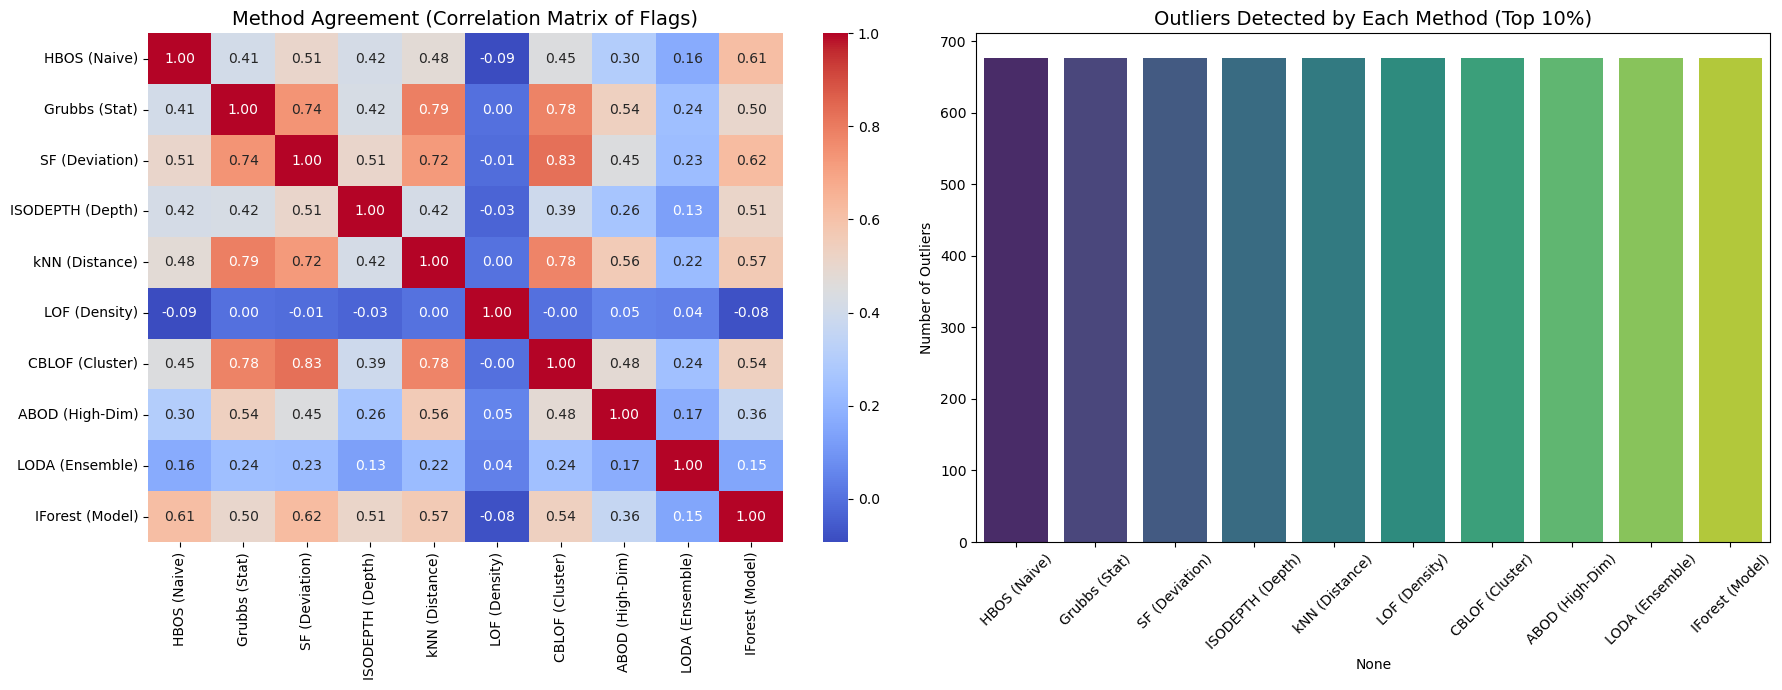

Interpretation: High correlation suggests methods detect similar structures.
CONSENSUS OUTLIER DETECTION (10 METHODS)
Total Outliers: 1 / 6768 (0.01%)

Breakdown by class (sii):
 - Class 0: 0 outliers (0.00% of class, 0.00% of total)
 - Class 1: 0 outliers (0.00% of class, 0.00% of total)
 - Class 2: 1 outliers (0.13% of class, 0.01% of total)
 - Class 3: 0 outliers (0.00% of class, 0.00% of total)


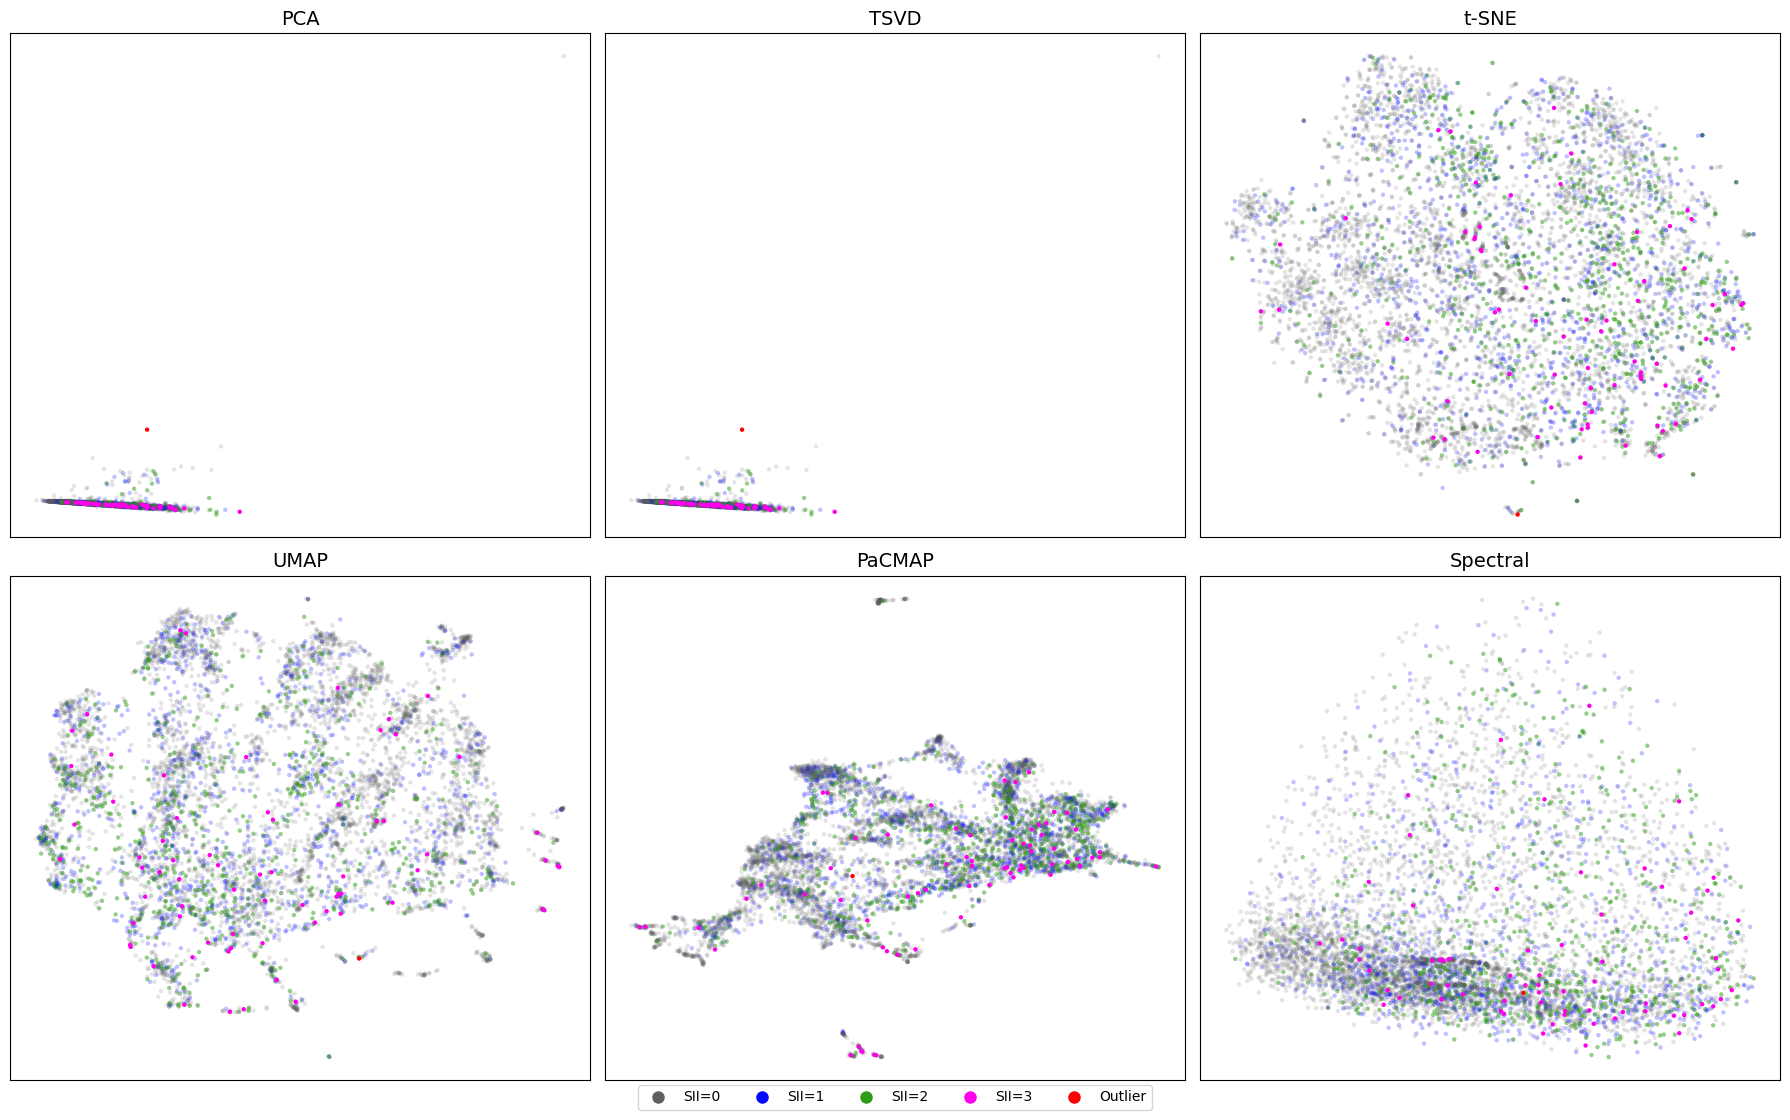

In [5]:
# --- Imputer search ---------------------------------------------------
benchmark_matrix = X_train.values.copy()
mask = create_mask(benchmark_matrix, p=IMPUTER_MASK_FRACTION)

print(f"Benchmark matrix: {benchmark_matrix.shape}")
print(f"Masked entries:   {mask.sum()} "
      f"({100 * mask.sum() / np.prod(benchmark_matrix.shape):.1f}% of cells)\n")

print(f"=== Classification Imputer Study ({IMPUTER_STUDY_TRIALS} trials) ===")
imputer_study = optuna.create_study(direction="minimize")
imputer_study.optimize(
    lambda trial: imputation_objective_classification(
        trial, benchmark_matrix, mask, y_labels=y_train.values),
    n_trials=IMPUTER_STUDY_TRIALS,
    show_progress_bar=True,
    n_jobs=IMPUTER_STUDY_N_JOBS,
)
print(f"Best (clf): {imputer_study.best_params}  "
      f"|  score={imputer_study.best_value:.4f}\n")

# --- Outlier detection ------------------------------------------------
# First: do the ten detectors agree with each other? (Top 10% per method.)
plot_method_agreement(compute_outlier_scores(X_train),
                      percentile=OUTLIER_COMPARE_PERCENTILE)

# Then the actual vote: top 1% per method, 9 of 10 must agree.
outlier_mask = summarise_outliers(
    detect_consensus_outliers(X_train, OUTLIER_PERCENTILE), y_train.values
)

# Finally: do the flagged rows separate visibly in 2D?
plot_outlier_embeddings(X_train, y_train.values, outlier_mask)

## 6. Class-imbalance diagnostic

Roughly 69% of children are class 0 and only ~1% are class 3, so a model can
score well on accuracy while never predicting a severe case at all. This cell
compares seven ways of correcting that, scored by Macro F1 with a fast
LightGBM proxy.

Each resampler runs *inside* the cross-validation folds (via an imblearn
pipeline). Resampling before splitting would leak synthetic copies of
validation rows into training and inflate every score.

**The outcome informed a decision, not a transformation.** No resampling is
applied to the saved dataset: the tuned models instead use
`class_weight='balanced'` (or `auto_class_weights='Balanced'` for CatBoost),
which reweights the loss rather than duplicating rows, and the project reports
Macro F1 rather than accuracy throughout.

In [6]:
compare_resampling_strategies(X_train, y_train)

# --- Export ------------------------------------------------------------
save_processed_split(X_train, y_train, X_test, y_test, outlier_mask,
                     PATHS["clf_processed"])
print()
validate_processed_file(PATHS["clf_processed"])
print("\nPostProcessed_clf.csv saved. Done.")

Method                    | Macro F1   | Recall     | Precision 
-----------------------------------------------------------------
Baseline (No Resampling)  | 0.2844     | 0.2890     | 0.3460    
SMOTE                     | 0.3078     | 0.3040     | 0.3489    
ADASYN                    | 0.3261     | 0.3182     | 0.3713    
ENN                       | 0.2208     | 0.2751     | 0.1862    
Tomek Links               | 0.2815     | 0.2873     | 0.3541    
SMOTE + ENN               | 0.3221     | 0.3618     | 0.3448    
SMOTE + Tomek             | 0.3151     | 0.3103     | 0.3508    
Rows written -> Train: 6768, Test: 1692
Outliers flagged in Train: 1 (0.01%)

Validation - Split values only Train/Test: True -> ['Test', 'Train']
Validation - sii non-null: True
Validation - sii classes in {0,1,2,3}: True -> [0, 1, 2, 3]
Validation - feature columns identical: True

PostProcessed_clf.csv saved. Done.
